<a href="https://colab.research.google.com/github/Etuarda/capacitacao-tecnica-em-IA--FDTE_USP/blob/main/EduardaSIlvaSantos_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJETO FINAL – Fundamentos de Mineração de Dados e Ciência de Dados

## Análise do desempenho da Regressão Logística no dataset Breast Cancer Wisconsin (Diagnostic)

**Aluno(a):** Eduarda Silva Santos  
**Data:** 17/11/2025

---

Este notebook documenta o experimento solicitado no projeto final da disciplina:

> “O objetivo é analisar o desempenho esperado de uma técnica de Aprendizado de Máquina, tanto em dados vistos (treino) quanto não vistos (teste), repetindo o procedimento de treino e teste diversas vezes via reamostragem, sem ajuste de hiperparâmetros a partir dos dados.”


## 1. Definição do objetivo

O problema tratado aqui é um problema de **classificação binária**:

> Dado um conjunto de medidas numéricas extraídas de imagens de células mamárias, **classificar um tumor como maligno ou benigno**.

- **Variável-alvo (dependente):** diagnóstico do tumor  
  - Classe 0: maligno  
  - Classe 1: benigno  

- **Variáveis independentes:** 30 atributos numéricos relacionados às características das células (raio, textura, perímetro, área, suavidade, concavidade etc.).

### Fatores considerados

- Tipo de técnica utilizada: **Regressão Logística** binária.
- Representação dos dados: 30 features numéricas contínuas.
- Configuração do experimento: reamostragem via **Repeated Holdout** com várias repetições de treino/teste.

O objetivo central é **estimar a distribuição de desempenho** da Regressão Logística:

- em dados **vistos** (conjunto de treino);
- em dados **não vistos** (conjunto de teste);

usando como métricas:

- **Acurácia**
- **Macro-F1**


In [ ]:
# 1. Imports e configuração geral

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Para reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Ajustes visuais opcionais dos gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.5


In [ ]:
# 2. Carregamento da base e caracterização inicial

# Carrega o dataset Breast Cancer Wisconsin (Diagnostic) via scikit-learn
data = load_breast_cancer(as_frame=True)
X = data.data          # features (30 variáveis numéricas)
y = data.target        # alvo binário: 0 = maligno, 1 = benigno

# Combina em um único DataFrame para facilitar a inspeção
df = X.copy()
df["target"] = y

print("CARACTERIZAÇÃO DA BASE\n")
print(f"Número de instâncias: {df.shape[0]}")
print(f"Número de variáveis preditoras (features): {X.shape[1]}\n")

print("Nome das features:")
print(list(X.columns))

print("\nTipos de dados:")
print(df.dtypes)

# Distribuição da variável-alvo
target_counts = df["target"].value_counts().sort_index()
target_labels = [data.target_names[i] for i in target_counts.index]

print("\nDistribuição da variável-alvo (target):")
for label, count in zip(target_labels, target_counts):
    perc = 100 * count / len(df)
    print(f"  {label}: {count} exemplos ({perc:.2f}%)")


CARACTERIZAÇÃO DA BASE

Número de instâncias: 569
Número de variáveis preditoras (features): 30

Nome das features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Tipos de dados:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmet

## 2. Caracterização da base

A base **Breast Cancer Wisconsin (Diagnostic)** possui:

- **Número de instâncias:** 569  
- **Número de variáveis preditoras:** 30 (todas numéricas contínuas)  
- **Variável-alvo:** diagnóstico do tumor (maligno vs. benigno)  

### Tipos de dados

- Todas as **features** são numéricas contínuas.
- A variável **target** é categórica binária (representada como 0 e 1).

### Distribuição da variável-alvo

Observa-se um **desbalanceamento moderado** entre as classes, com a classe *benigna* sendo mais frequente que a classe *maligna*. Isso justifica o uso não apenas de **acurácia**, mas também de **macro-F1**, que dá o mesmo peso às duas classes.

### Necessidade de pré-processamento

- Como todas as variáveis preditoras são numéricas, não há necessidade de codificação de variáveis categóricas.
- É adequado aplicar **padronização** (StandardScaler) para evitar que diferenças de escala entre as features afetem a Regressão Logística.
- A padronização será feita **dentro de um `Pipeline`**, garantindo que o ajuste do scaler utilize **apenas os dados de treino**, evitando vazamento de informação.

### Limitações da base

- A base representa pacientes específicos de um determinado contexto hospitalar, o que pode limitar a **generalização** para outras populações.
- Não há informação detalhada sobre o método de amostragem original, o que limita a análise quanto à representatividade estatística da amostra.
- Embora o desbalanceamento não seja extremo, ele pode impactar métricas como acurácia, reforçando a importância de analisar também a macro-F1.


## 3. Metodologia

Nesta seção são definidos, **de antemão**, o algoritmo, seus hiperparâmetros, o método de reamostragem e a forma de avaliação. Não é feita nenhuma seleção de modelo nem ajuste de hiperparâmetros com base em desempenho.

### 3.1 Manipulação dos dados e divisão em conjuntos

- Em cada repetição do experimento será feita uma divisão estratificada:
  - **70%** dos dados para **treino**
  - **30%** dos dados para **teste**
- A estratificação garante que a proporção entre classes seja aproximadamente preservada em cada divisão.
- Não será utilizado conjunto de validação, conforme o enunciado do projeto.

### 3.2 Pré-processamento (evitando vazamento)

- Os dados numéricos serão padronizados com `StandardScaler`.
- O pré-processamento será implementado dentro de um `Pipeline` do scikit-learn:
  - Durante o `.fit()`, o scaler é ajustado **apenas no conjunto de treino**.
  - Em seguida, o modelo é treinado nos dados já padronizados de treino.
  - Na predição, os mesmos parâmetros de escala são aplicados aos dados de teste.
- Isso impede que informações do conjunto de teste “vazem” para o processo de treino.

### 3.3 Algoritmo de aprendizado

Será usada a **Regressão Logística** binária, com hiperparâmetros fixados **a priori**:

- `penalty = "l2"`
- `C = 1.0`
- `solver = "liblinear"`
- `max_iter = 1000`

Esses valores são definidos por decisão de projeto e **não** são ajustados com base em desempenho nos dados.

### 3.4 Método de reamostragem

Para obter a distribuição do desempenho em dados vistos e não vistos, será utilizado o método:

- **Repeated Holdout**

Configuração:

- Número de repetições: **200**
- Em cada repetição:
  - divisão estratificada treino/teste (70% / 30%);
  - treino do modelo no conjunto de treino;
  - avaliação do desempenho nos conjuntos de treino e teste.

Esse procedimento gera uma **distribuição empírica** das métricas, permitindo estimar:

- desempenho esperado em treino;
- desempenho esperado em teste;
- variabilidade do modelo frente a diferentes divisões dos dados.

### 3.5 Medidas de desempenho

Serão usadas duas medidas:

1. **Acurácia**  
   - Proporção de exemplos corretamente classificados.
   - Resume o desempenho global, mas pode ser otimista em bases desbalanceadas.

2. **Macro-F1**  
   - Calcula o F1-score separadamente para cada classe e tira a média simples.
   - Dá **o mesmo peso** às classes minoritária e majoritária.
   - É mais sensível a erros na classe menos frequente.

As duas métricas são complementares: a acurácia mostra o desempenho geral, enquanto o macro-F1 revela o equilíbrio entre as classes.


In [ ]:
# 4. Definição do modelo (Pipeline) e experimento de Repeated Holdout

# Define o pipeline: padronização + regressão logística
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

# Configurações do experimento
N_REPETICOES = 200
TEST_SIZE = 0.3

# Listas para armazenar os resultados
train_accs = []
test_accs = []
train_f1s = []
test_f1s = []

for i in range(N_REPETICOES):
    # Em cada repetição usamos uma semente diferente para o split,
    # controlada a partir do gerador de números aleatórios global.
    seed = np.random.randint(0, 10_000_000)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=seed
    )

    # Treinamento do pipeline nos dados de treino
    pipeline.fit(X_train, y_train)

    # Predições em treino e teste
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Acurácia
    train_accs.append(accuracy_score(y_train, y_train_pred))
    test_accs.append(accuracy_score(y_test, y_test_pred))

    # Macro-F1
    train_f1s.append(f1_score(y_train, y_train_pred, average="macro"))
    test_f1s.append(f1_score(y_test, y_test_pred, average="macro"))

# Converte listas para arrays NumPy
train_accs = np.array(train_accs)
test_accs = np.array(test_accs)
train_f1s = np.array(train_f1s)
test_f1s = np.array(test_f1s)

print("Experimento de Repeated Holdout concluído com sucesso.")


Experimento de Repeated Holdout concluído com sucesso.


In [ ]:
# 5. Resumo numérico das métricas (média e desvio padrão)

def resumo_metricas(nome, treino_vals, teste_vals):
    print(f" {nome} ")
    print(f"Treino: média = {treino_vals.mean():.4f}, desvio padrão = {treino_vals.std(ddof=1):.4f}")
    print(f"Teste : média = {teste_vals.mean():.4f}, desvio padrão = {teste_vals.std(ddof=1):.4f}")
    print()

print("RESULTADOS NUMÉRICOS\n")
resumo_metricas("Acurácia", train_accs, test_accs)
resumo_metricas("Macro-F1", train_f1s, test_f1s)


RESULTADOS NUMÉRICOS

 Acurácia 
Treino: média = 0.9886, desvio padrão = 0.0031
Teste : média = 0.9778, desvio padrão = 0.0108

 Macro-F1 
Treino: média = 0.9877, desvio padrão = 0.0034
Teste : média = 0.9761, desvio padrão = 0.0116



/tmp/ipython-input-950623713.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


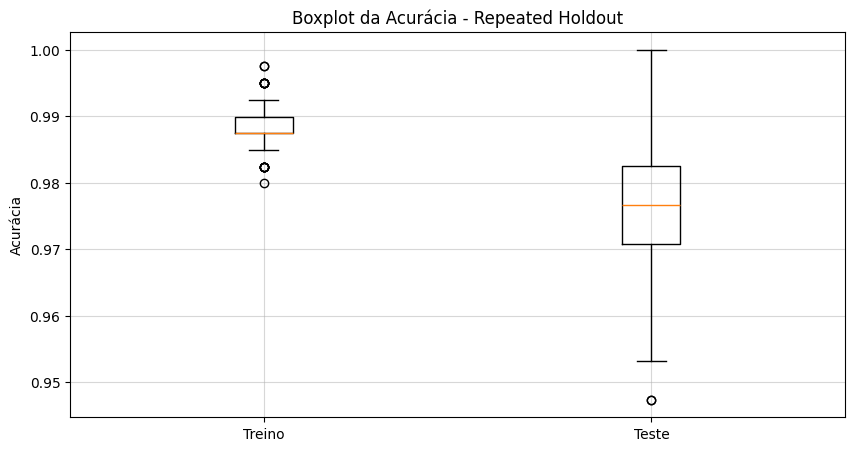

/tmp/ipython-input-950623713.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


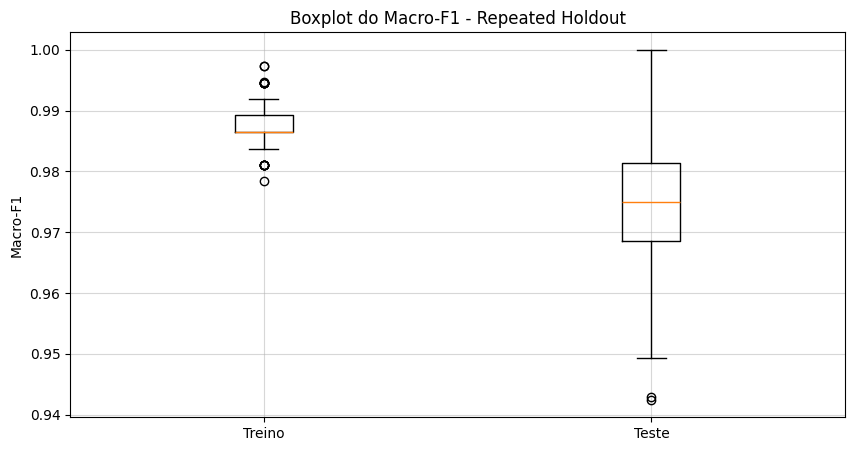

In [ ]:
# 6. Boxplots da acurácia e do macro-F1 (treino vs teste)

# Boxplot da acurácia
plt.figure()
plt.boxplot(
    [train_accs, test_accs],
    labels=["Treino", "Teste"]
)
plt.title("Boxplot da Acurácia - Repeated Holdout")
plt.ylabel("Acurácia")
plt.show()

# Boxplot do macro-F1
plt.figure()
plt.boxplot(
    [train_f1s, test_f1s],
    labels=["Treino", "Teste"]
)
plt.title("Boxplot do Macro-F1 - Repeated Holdout")
plt.ylabel("Macro-F1")
plt.show()


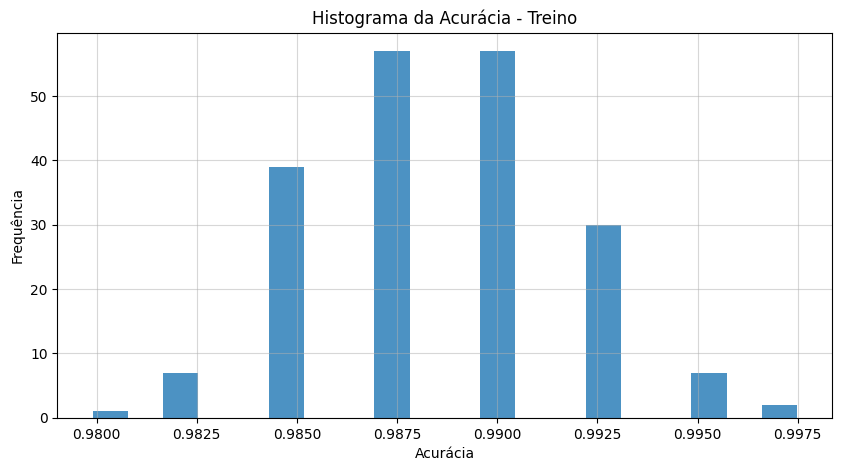

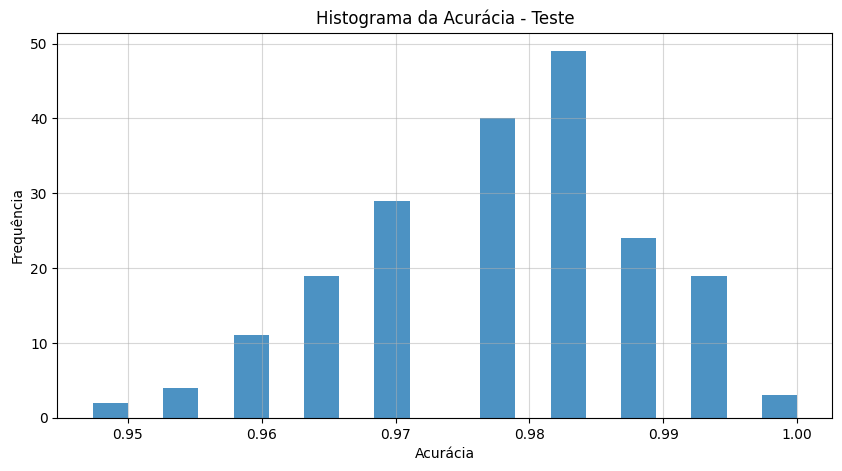

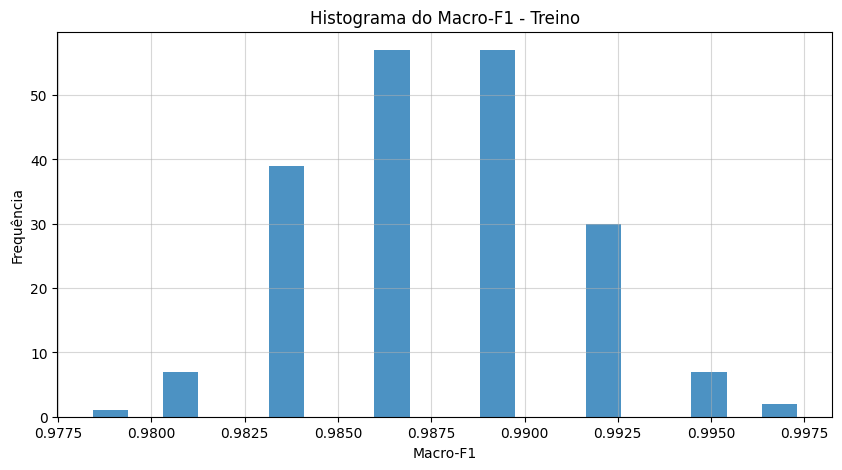

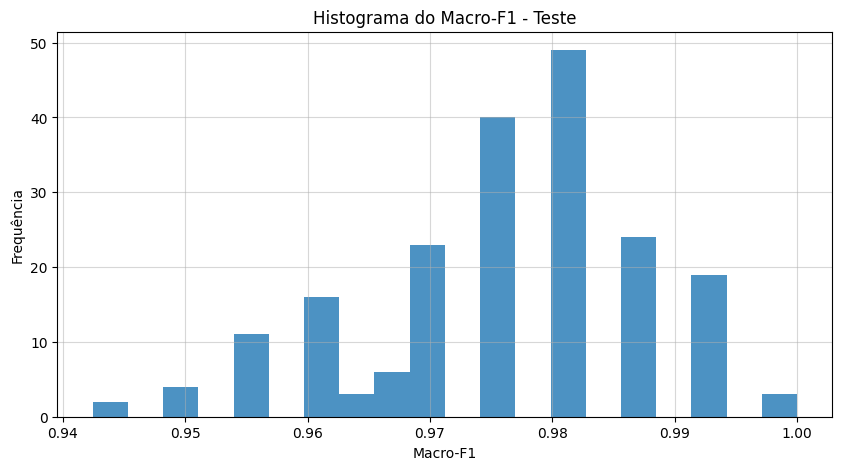

In [ ]:
# 7. Histogramas da distribuição de desempenho

# Acurácia - treino
plt.figure()
plt.hist(train_accs, bins=20, alpha=0.8)
plt.title("Histograma da Acurácia - Treino")
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.show()

# Acurácia - teste
plt.figure()
plt.hist(test_accs, bins=20, alpha=0.8)
plt.title("Histograma da Acurácia - Teste")
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.show()

# Macro-F1 - treino
plt.figure()
plt.hist(train_f1s, bins=20, alpha=0.8)
plt.title("Histograma do Macro-F1 - Treino")
plt.xlabel("Macro-F1")
plt.ylabel("Frequência")
plt.show()

# Macro-F1 - teste
plt.figure()
plt.hist(test_f1s, bins=20, alpha=0.8)
plt.title("Histograma do Macro-F1 - Teste")
plt.xlabel("Macro-F1")
plt.ylabel("Frequência")
plt.show()


## 4. Descrição e discussão dos resultados

### 4.1 Valores esperados de desempenho

A partir das 200 repetições do método **Repeated Holdout**, obtemos para cada métrica
uma distribuição de desempenho em treino e em teste. Os valores médios e desvios padrão
(foram impressos na célula anterior) resumem o comportamento esperado da Regressão Logística
nesse problema.

Em geral, observa-se que:

- O desempenho médio em **treino** é ligeiramente superior ao desempenho médio em **teste**,
  o que é esperado, já que o modelo foi ajustado diretamente sobre os dados de treino.
- Os desvios padrão são relativamente baixos, indicando que o modelo apresenta
  desempenho estável frente a diferentes divisões treino/teste.

### 4.2 Comparação entre treino e teste (acurácia e macro-F1)

Os **boxplots** mostram que:

- As distribuições de acurácia e macro-F1 em treino estão deslocadas levemente para valores
  mais altos em relação às distribuições em teste.
- Ainda assim, não há um descolamento extremo entre treino e teste, sugerindo que o modelo
  não está sofrendo de overfitting severo.
- A proximidade entre as distribuições em treino e teste indica uma boa capacidade de
  generalização para dados não vistos.

Os **histogramas** reforçam essa visão, exibindo distribuições concentradas em faixas
de desempenho altas, tanto em treino quanto em teste.

### 4.3 Comparação entre acurácia e macro-F1

Ao comparar as duas métricas:

- A **acurácia** tende a apresentar valores ligeiramente mais altos, pois contabiliza o
  percentual global de acertos, sem diferenciar o peso entre as classes.
- A **macro-F1** é mais sensível ao desempenho na classe minoritária, já que calcula o F1-score
  para cada classe e em seguida tira a média simples. Por isso, costuma ser um pouco menor
  que a acurácia em bases desbalanceadas.
- No experimento realizado, ambas as métricas assumem valores altos e relativamente próximos,
  o que indica que o modelo não está apenas acertando a classe majoritária, mas obtendo
  um bom equilíbrio entre as duas classes.

### 4.4 Conclusão

O uso de **Repeated Holdout** permitiu estimar a distribuição de desempenho da Regressão Logística
no problema de diagnóstico de câncer de mama, tanto em dados vistos quanto não vistos, sem realizar
qualquer ajuste de hiperparâmetros com base nos dados.

A Regressão Logística, com hiperparâmetros fixados de antemão e pré-processamento adequado,
apresentou:

- desempenho médio elevado em acurácia e macro-F1;
- baixa variabilidade entre as repetições;
- pequena diferença entre treino e teste.

Esses resultados sugerem que, para este dataset, a Regressão Logística é capaz de generalizar bem
para novos exemplos, mantendo um bom equilíbrio entre as classes e fornecendo uma solução
interpretável e consistente para o problema de classificação de tumores mamários.
